1.html, 2.html

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
import IPython.display
BRIGHT_BLACK = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
BRIGHT_WHITE = '\033[97m'
BRIGHT_END = '\033[0m'

In [2]:
filepath = "data/서울시_공공_자전거_이용정보(시간대별)_2022년도"
all_path = glob(filepath + "/*.csv")
print(len(all_path))
for i in all_path:
    print(i[57:])
# 2022년 1월~12월 데이터

# 데이터 하나 불러와서 확인
display(pd.read_csv(all_path[0], encoding = 'cp949').head(2))

12
서울특별시 공공자전거 이용정보(시간대별)_22.01.csv
서울특별시 공공자전거 이용정보(시간대별)_22.02.csv
서울특별시 공공자전거 이용정보(시간대별)_22.03.csv
서울특별시 공공자전거 이용정보(시간대별)_22.04.csv
서울특별시 공공자전거 이용정보(시간대별)_22.05.csv
서울특별시 공공자전거 이용정보(시간대별)_22.06.csv
서울특별시 공공자전거 이용정보(시간대별)_22.07.csv
서울특별시 공공자전거 이용정보(시간대별)_22.08.csv
서울특별시 공공자전거 이용정보(시간대별)_22.09.csv
서울특별시 공공자전거 이용정보(시간대별)_22.10.csv
서울특별시 공공자전거 이용정보(시간대별)_22.11.csv
서울특별시 공공자전거 이용정보(시간대별)_22.12.csv


,대여일자,대여시간,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,2022-01-01,0,1725,1725. 창1동주민센터,정기권,NaN,~10대,1,0.00,0.00,0.0,44
1,2022-01-01,0,1167,1167. 마곡수명산파크3단지 교차로,정기권,NaN,~10대,1,52.51,0.51,2210.0,15


# 2022년도 자전거 데이터 합치기

In [3]:
# 12 개의 모든 파일의 칼럼명과 순서가 동일함을 확인하기기
all_cols = pd.read_csv(all_path[0], encoding = 'cp949').columns.to_list()
for path in all_path:
    col = list(pd.read_csv(path, encoding = 'cp949', skiprows = lambda x : x>2).columns)
    if all_cols != col:
        print(path[57:], ": no")
    else:
        print(path[57:], ": ok")
        
print(f"\n컬럼 명 : {all_cols}")
# 12개의 파일이 모두 같은 컬럼 구성을 가짐

서울특별시 공공자전거 이용정보(시간대별)_22.01.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.02.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.03.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.04.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.05.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.06.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.07.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.08.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.09.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.10.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.11.csv : ok
서울특별시 공공자전거 이용정보(시간대별)_22.12.csv : ok

컬럼 명 : ['대여일자', '대여시간', '대여소번호', '대여소명', '대여구분코드', '성별', '연령대코드', '이용건수', '운동량', '탄소량', '이동거리(M)', '이용시간(분)']


## 필요한 column만 뽑아오기

- 대여소명과 대여소번호는 1대1 대응이므로 대여소번호만 사용. 대여소명은 제거

['대여일자', '대여시간', '대여소번호', '대여소명', '대여구분코드', '성별', '연령대코드', '이용건수', '운동량', '탄소량', '이동거리(M)', '이용시간(분)']

In [73]:
interested = ['대여일자','대여시간','대여소번호','대여구분코드','성별',  '연령대코드',
             '운동량', '이용건수', '이용시간(분)', '탄소량', '이동거리(M)']

all_df = pd.DataFrame()

# 12개의 파일을 하나로 합치기
for path in all_path:
    single = pd.read_csv(path, encoding = 'cp949')
    
    all_df = pd.concat([all_df, single[interested]])
    print(all_df.shape)

    del single

(1339969, 11)
(2611345, 11)
(4829981, 11)
(8334705, 11)
(12623928, 11)
(16328256, 11)
(19930332, 11)
(23117903, 11)
(27218587, 11)
(31121495, 11)
(34521518, 11)
(36160487, 11)


# nan 값 처리

In [74]:
print(all_df.isna().sum())
print(all_df.shape)
print(all_df.columns)

대여일자              0
대여시간              0
대여소번호             0
대여구분코드            0
성별         12315127
연령대코드             0
운동량               0
이용건수              0
이용시간(분)           0
탄소량               0
이동거리(M)           0
dtype: int64
(36160487, 11)
Index(['대여일자', '대여시간', '대여소번호', '대여구분코드', '성별', '연령대코드', '운동량', '이용건수',
       '이용시간(분)', '탄소량', '이동거리(M)'],
      dtype='object')


In [75]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36160487 entries, 0 to 1638968
Data columns (total 11 columns):
 #   Column   Dtype  
---  ------   -----  
 0   대여일자     object 
 1   대여시간     int64  
 2   대여소번호    int64  
 3   대여구분코드   object 
 4   성별       object 
 5   연령대코드    object 
 6   운동량      object 
 7   이용건수     int64  
 8   이용시간(분)  int64  
 9   탄소량      object 
 10  이동거리(M)  float64
dtypes: float64(1), int64(4), object(6)
memory usage: 3.2+ GB


## 대여일자
- nan 값이 없음
- 2022-01-01 ~ 2022-12-31   
➡️ 변경 X

In [76]:
all_df['대여일자'] = pd.to_datetime(all_df['대여일자'])
# 대여일자 범위
print(all_df['대여일자'].min(),'~' ,all_df['대여일자'].max())

2022-01-01 00:00:00 ~ 2022-12-31 00:00:00


## 대여시간
- nan 값이 없음
- 0 ~ 23
➡️ 변경 X

In [77]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36160487 entries, 0 to 1638968
Data columns (total 11 columns):
 #   Column   Dtype         
---  ------   -----         
 0   대여일자     datetime64[ns]
 1   대여시간     int64         
 2   대여소번호    int64         
 3   대여구분코드   object        
 4   성별       object        
 5   연령대코드    object        
 6   운동량      object        
 7   이용건수     int64         
 8   이용시간(분)  int64         
 9   탄소량      object        
 10  이동거리(M)  float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 3.2+ GB


In [78]:
print(all_df['대여시간'].min(), '~',all_df['대여시간'].max())

0 ~ 23


## 대여소번호
- nan 값이 없음
- 3 ~ 99999
➡️ 변경 X

In [79]:
print(np.unique(all_df['대여소번호']))
print(all_df['대여소번호'].min(), '~', all_df['대여소번호'].max())

[    3     5    10 ... 88888 99998 99999]
3 ~ 99999


## 대여구분코드
- 일일권과 일일권(비회원)을 같은 종류로 만들어 줌 

| 대여구분코드 | 변경 |
| --- | --- |
| 정기권 | regular |
| 일일권 | casual |
| 일일권(비회원) | casual |
| 단체권 | group |


In [80]:
all_df['대여구분코드'].value_counts()
# 일일권과 일일권(비회원)은 같은 의미로 보고 하나로 합칠 예정

대여구분코드
정기권         29149889
일일권          6490856
일일권(비회원)      327618
단체권           192124
Name: count, dtype: int64

In [81]:
mapper = {'단체권' : 'group',
           '일일권' : 'casual',
           '일일권(비회원)' : 'casual',
            '정기권' : 'regular'}

all_df['type'] = all_df['대여구분코드'].map(mapper)
all_df = all_df.drop(['대여구분코드'], axis = 'columns')
all_df['type'].value_counts()

type
regular    29149889
casual      6818474
group        192124
Name: count, dtype: int64

In [82]:
# nan 비율
all_df.isna().sum() / all_df.shape[0]

대여일자       0.000000
대여시간       0.000000
대여소번호      0.000000
성별         0.340569
연령대코드      0.000000
운동량        0.000000
이용건수       0.000000
이용시간(분)    0.000000
탄소량        0.000000
이동거리(M)    0.000000
type       0.000000
dtype: float64

## 성별
- 약 34%가 nan 값 ➡️ 지우는건 무리라고 판단 -> U(Unidentified)로 변경
- F,f 는 F(female)로 통일 & M,m은 M(Male)로 통일

| 성별 | 변경 |
| --- | ---
F | F
f | F
M | M
m | M
nan | U

In [83]:
all_df['성별'].unique()

array([nan, 'F', 'M', 'f', 'm'], dtype=object)

In [84]:
mapper = {'F' : 'F',
         'f' : 'F',
         'M' : 'M',
         'm' : 'M'}

all_df['gender'] = all_df['성별'].map(mapper)
all_df.drop(['성별'], axis = 'columns', inplace = True)
all_df['gender'] = all_df['gender'].fillna('U')
all_df['gender'].value_counts()

gender
M    14463309
U    12315127
F     9382051
Name: count, dtype: int64

## 연령대코드
- nan 값이 없음
- 매핑 다시 해줌

| 연령대코드 | 변경 |
| --- | --- |
| ~10대 | 10s |
| 20대 | 20s |
| 30대 | 30s |
| 40대 | 40s |
| 50대 | 50s |
| 60대 | 60s |
| 70대이상 | 70s |
|기타 | unknown


In [86]:
all_df['연령대코드'].unique()

array(['~10대', '20대', '30대', '40대', '50대', '60대', '70대이상', '기타'],
      dtype=object)

In [ ]:
mapper = {'20대' : '20s',
          '30대' : '30s',
          '40대' : '40s',
          '50대' : '50s',
          '60대' : '60s',
          '70대이상' : '70s',
          '기타' : 'unknown',
          '~10대' : '10s'}

all_df['age'] = all_df['연령대코드'].map(mapper)
all_df = all_df.drop(['연령대코드'], axis = 'columns')
all_df['age'].value_counts()

age
20s        12269689
30s         8379787
40s         5165806
unknown     3567691
50s         3424307
10s         2128535
60s         1071253
70s          153419
Name: count, dtype: int64

## 운동량
- nan 값이 없음
- \\N 라는 이상한 값이 있음    
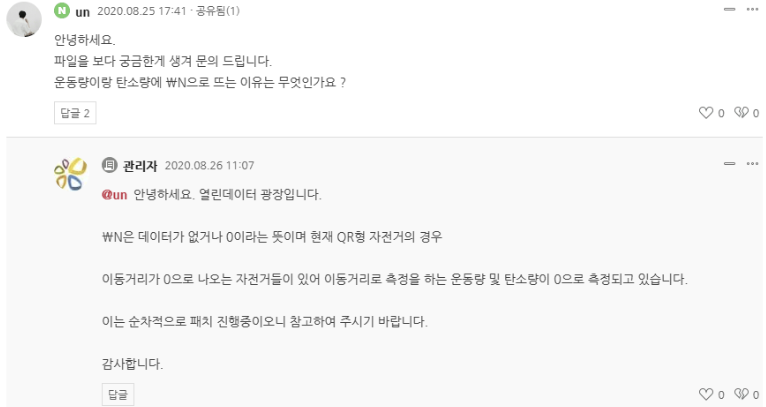

- 이동량과 탄소량을 확인해본 결과 운동량이 \\n인 경우 이동량은 0, 탄소량은 \\n 이었음
➡️ 운동량과 탄소량이 \\n인 경우 운동량과 탄소량을 0으로 변경

In [100]:
# 운동량 칼럼을 숫자로 변환, 변환 불가능한 값 찾기
df_invalid = all_df[pd.to_numeric(all_df['운동량'], errors='coerce').isna()]

# 변환되지 않는 값들만 출력
print("숫자로 변환되지 않는 값들:")
print(df_invalid['운동량'].unique())

숫자로 변환되지 않는 값들:
['\\N']


In [118]:
exercise_strange = all_df[all_df['운동량'] == '\\N']
# 운동량이 \N인 경우 이동거리와 탄소량 확인
print("운동량이 \\N인 경우 이동거리와 탄소량:")
print(f"이동거리 : {exercise_strange['이동거리(M)'].unique()}")
print(f"탄소량 : {exercise_strange['탄소량'].unique()}")
if exercise_strange['이동거리(M)'].eq(0).all() and exercise_strange['탄소량'].eq('\\N').all():
    print(f"{BRIGHT_BLUE}운동량이 '\\N'인 경우 이동거리는 0, 탄소량은 '\\N'을 확인{BRIGHT_END}\n")
else:
    print('\n')
# 운동량이 \N인 경우 이동거리는 0이고 탄소량은 '\\N'을 확인

# 이동거리가 0인 경우 운동량과 탄소량 확인
distance_zero = all_df[all_df['이동거리(M)'] == 0]
print("이동거리가 0인 경우 운동량과 탄소량:")
print(f"운동량 : {distance_zero['운동량'].unique()}")
print(f"탄소량 : {distance_zero['탄소량'].unique()}")
if distance_zero['운동량'].eq('\\N').all() and distance_zero['탄소량'].eq('\\N').all():
    print(f"{BRIGHT_BLUE}이동거리가 0인 경우 운동량과 탄소량은 '\\N'을 확인{BRIGHT_END}\n")
else:
    print('\n')
# 탄소량이 \N인 경우 운동량과 이동거리 확인
carbon_strange = all_df[all_df['탄소량'] == '\\N']
print("탄소량이 \\N인 경우 운동량과 이동거리:")
print(f"운동량 : {carbon_strange['운동량'].unique()}")
print(f"이동거리 : {carbon_strange['이동거리(M)'].unique()}")
if carbon_strange['운동량'].eq('\\N').all() and carbon_strange['이동거리(M)'].eq(0).all():
    print(f"{BRIGHT_BLUE}탄소량이 '\\N'인 경우 운동량과 이동거리는 0을 확인{BRIGHT_END}\n")
else:
    print('\n\n')
    
# 운동량이 \N인 경우와 탄소량이 \N인 경우가 동일한 row인지 확인
exercise_carbon = all_df[(all_df['운동량'] == '\\N') & (all_df['탄소량'] == '\\N')]
print("운동량과 탄소량 둘 다 \\N인 경우:")
print(exercise_carbon.shape,'\n')
print("운동량만 \\N인 경우:")
print(all_df[all_df['운동량'] == '\\N'].shape,'\n')
print("탄소량만 \\N인 경우:")
print(all_df[all_df['탄소량'] == '\\N'].shape)

if exercise_carbon.shape[0] == all_df[all_df['운동량'] == '\\N'].shape[0] and exercise_carbon.shape[0] == all_df[all_df['탄소량'] == '\\N'].shape[0]:
    print(f"{BRIGHT_GREEN}운동량과 탄소량이 모두 '\\N'인 경우가 같음을 확인{BRIGHT_END}\n")

운동량이 \N인 경우 이동거리와 탄소량:
이동거리 : [0.]
탄소량 : ['\\N']
운동량이 '\N'인 경우 이동거리는 0, 탄소량은 '\N'을 확인

이동거리가 0인 경우 운동량과 탄소량:
운동량 : ['0.00' '\\N']
탄소량 : ['0.00' '\\N']


탄소량이 \N인 경우 운동량과 이동거리:
운동량 : ['\\N']
이동거리 : [0.]
탄소량이 '\N'인 경우 운동량과 이동거리는 0을 확인

운동량과 탄소량 둘 다 \N인 경우:
(137401, 11) 

운동량만 \N인 경우:
(137401, 11) 

탄소량만 \N인 경우:
(137401, 11)
운동량과 탄소량이 모두 '\N'인 경우가 같음을 확인



In [120]:
all_df.replace({'운동량' : {'\\N': '0.00'}}, inplace = True)
all_df['운동량'] = all_df['운동량'].astype(float)

all_df.replace({'탄소량' : {'\\N': '0.00'}}, inplace = True)
all_df['탄소량'] = all_df['탄소량'].astype(float)

## 이용건수
- nan 값이 없음
- 특정 시간대에 공공자전거가 대여된 횟수를 나타냅니다. 즉, 각 시간대별로 얼마나 많은 자전거 대여가 발생했는지를 보여주는 지표    
➡️ 변경 X

In [122]:
all_df['이용건수'].unique()

array([ 1,  2,  3,  5,  6,  4,  8,  7, 11, 10, 12,  9, 13, 14, 19, 15, 38,
       20, 34, 29, 30, 24, 18, 17, 16, 23, 25, 21, 22, 26, 36, 31, 27, 28],
      dtype=int64)

## 이용시간(분)
- nan 값이 없음    
➡️ 변경 X

In [124]:
np.unique(all_df['이용시간(분)'])

array([   0,    1,    2, ..., 2559, 2574, 3205], dtype=int64)

## 탄소량
- \N이라는 이상한 값 포함 => 운동량 처리할 때 모두 0으로 변경함

In [125]:
all_df.head()

,대여일자,대여시간,대여소번호,운동량,이용건수,이용시간(분),탄소량,이동거리(M),type,gender,age
0,2022-01-01,0,1725,0.00,1,44,0.00,0.0,regular,U,10s
1,2022-01-01,0,1167,52.51,1,15,0.51,2210.0,regular,U,10s
2,2022-01-01,0,1059,25.66,1,4,0.25,1080.0,regular,U,10s
3,2022-01-01,0,3794,49.61,1,15,0.50,2160.0,regular,U,10s
4,2022-01-01,0,4014,23.60,1,7,0.22,961.3,regular,U,10s


## 이동거리(M)
- nan 값이 없음   
➡️ 변경 X

In [126]:
np.unique(all_df['이동거리(M)'], return_counts = True)

(array([-1.37067800e+04,  0.00000000e+00,  1.00000000e-01, ...,
         1.31747916e+07,  1.31791590e+07,  1.41102791e+07]),
 array([      1, 1415214,   14069, ...,       1,       1,       1],
       dtype=int64))

In [128]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36160487 entries, 0 to 1638968
Data columns (total 11 columns):
 #   Column   Dtype         
---  ------   -----         
 0   대여일자     datetime64[ns]
 1   대여시간     int64         
 2   대여소번호    int64         
 3   운동량      float64       
 4   이용건수     int64         
 5   이용시간(분)  int64         
 6   탄소량      float64       
 7   이동거리(M)  float64       
 8   type     object        
 9   gender   object        
 10  age      object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(3)
memory usage: 3.2+ GB


# datetime 만들기

In [129]:
all_df.to_csv('data/data_checkpoint1.csv', index = False)
# 2.html까지 한거임

In [7]:
all_df = pd.read_csv('data/data_checkpoint1.csv')

In [8]:
all_df = all_df.astype({ '대여시간' : 'str' })
all_df = all_df.astype({ '대여시간' : 'str' })
all_df['datetime'] = all_df['대여일자'] + ' ' + all_df['대여시간'] + ':00:00'
all_df.drop(['대여일자', '대여시간'], axis = 'columns', inplace = True)
all_df.head()

,대여소번호,운동량,이용건수,이용시간(분),탄소량,이동거리(M),type,gender,age,datetime
0,1725,0.00,1,44,0.00,0.0,regular,U,10s,2022-01-01 0:00:00
1,1167,52.51,1,15,0.51,2210.0,regular,U,10s,2022-01-01 0:00:00
2,1059,25.66,1,4,0.25,1080.0,regular,U,10s,2022-01-01 0:00:00
3,3794,49.61,1,15,0.50,2160.0,regular,U,10s,2022-01-01 0:00:00
4,4014,23.60,1,7,0.22,961.3,regular,U,10s,2022-01-01 0:00:00


In [9]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36160487 entries, 0 to 36160486
Data columns (total 10 columns):
 #   Column    Dtype  
---  ------    -----  
 0   대여소번호     int64  
 1   운동량       float64
 2   이용건수      int64  
 3   이용시간(분)   int64  
 4   탄소량       float64
 5   이동거리(M)   float64
 6   type      object 
 7   gender    object 
 8   age       object 
 9   datetime  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 2.7+ GB


In [10]:
all_df.to_csv('data/data_checkpoint2.csv', index = False) # 3.html까지

In [4]:
all_df = pd.read_csv('data/data_checkpoint2.csv')
all_df.head()

,대여소번호,운동량,이용건수,이용시간(분),탄소량,이동거리(M),type,gender,age,datetime
0,1725,0.00,1,44,0.00,0.0,regular,U,10s,2022-01-01 0:00:00
1,1167,52.51,1,15,0.51,2210.0,regular,U,10s,2022-01-01 0:00:00
2,1059,25.66,1,4,0.25,1080.0,regular,U,10s,2022-01-01 0:00:00
3,3794,49.61,1,15,0.50,2160.0,regular,U,10s,2022-01-01 0:00:00
4,4014,23.60,1,7,0.22,961.3,regular,U,10s,2022-01-01 0:00:00


# Weather Crawling
- 날씨 데이터는 2022년 1월 1일부터 12월 31일까지의 데이터를 수집

In [ ]:
# 달 리스트 만들기
mon = []
for month in range(1,13):
    mon.append(month)

mon = list(map(str, mon))

mont = []

for i in range (len(mon)):
    mont.append('0' +mon[i])

month = []    
for i in range (len(mon)):
    month.append(mont[i][-2:])
    
print(month)
# 일 리스트 만들기
d = []
for i in range(1,32):
    d.append(i)

d = list(map(str, d))

da = []

for i in range (len(d)):
    da.append('0' +d[i])

day = []    
for i in range (len(d)):
    day.append(da[i][-2:])
    
print(day)
date = []

for m in month:
    for d in day:
        date.append('2022-'+ m + '-' + d)
remove_date = ['2022-02-29','2022-02-30','2022-02-31',
            '2022-04-31','2022-06-31' ,'2022-09-31',
            '2022-11-31']
for i in remove_date:
    date.remove(i)
print(len(date))
url = 'https://freemeteo.co.uk/weather/seoul/history/daily-history/?gid=1835848&station=10565&date='
end = '&language=english&country=south-korea'

seoul_weather = []

for d in date:
    html_list = pd.read_html(url + d + end)
    seoul_weather.append(html_list[6])
for i, d in enumerate(date):
        seoul_weather[i]['date'] = d
        
weather = pd.DataFrame()

for i in seoul_weather:
    weather = pd.concat([weather, i])     
weather.to_csv('data/weather_2022_01_01to2022_12_31.csv',index = False)
weather.head()

,Time,Temperature,Relative Temperature,Wind,Wind Gust,Rel. humidity,Dew Point,Pressure,Icon,DescriptionDetails,date
0,00:00,-9°C,-13°C,10°7 Km/h,NaN,48%,-18°C,1033.0mb,NaN,"document.write(Icons.GetShortDescription(1, 'C...",2022-01-01
1,01:00,-11°C,-14°C,300°6 Km/h,NaN,62%,-17°C,1033.0mb,NaN,"document.write(Icons.GetShortDescription(1, 'C...",2022-01-01
2,02:00,-11°C,-11°C,110°2 Km/h,NaN,62%,-17°C,1033.0mb,NaN,"document.write(Icons.GetShortDescription(1, 'C...",2022-01-01
3,03:00,-12°C,-12°C,80°2 Km/h,NaN,61%,-18°C,1034.0mb,NaN,"document.write(Icons.GetShortDescription(1, 'C...",2022-01-01
4,04:00,-13°C,-13°C,300°4 Km/h,NaN,72%,-17°C,1033.0mb,NaN,"document.write(Icons.GetShortDescription(1, 'C...",2022-01-01


### 크롤링한 날씨 데이터 전처리

In [90]:
# weather = pd.read_csv('data/weather_2022_01_01to2022_12_31.csv')

In [91]:
print(set(weather['Time'].apply(lambda x : len(x)))) # {5}
print(set(weather['Time'].apply(lambda x : x[:2]))) # {'13', '11', '00', '10', '04', '21', '02', '06', '01', '20', '14', '09', '16', '07', '05', '12', '18', '17', '15', '22', '03', '19', '23', '08'}
print(set(weather['Time'].apply(lambda x : x[2:]))) # {':30', ':56', ':32', ':09', ':23', ':33', ':46', '..

{5}
{'13', '11', '00', '10', '04', '21', '02', '06', '01', '20', '14', '09', '16', '07', '05', '12', '18', '17', '15', '22', '03', '19', '23', '08'}
{':30', ':56', ':32', ':09', ':23', ':33', ':46', ':21', ':06', ':05', ':11', ':35', ':47', ':37', ':27', ':10', ':51', ':03', ':34', ':40', ':44', ':29', ':57', ':43', ':55', ':04', ':16', ':39', ':38', ':28', ':58', ':15', ':14', ':50', ':31', ':22', ':12', ':24', ':08', ':19', ':17', ':13', ':59', ':48', ':42', ':41', ':07', ':26', ':49', ':36', ':54', ':18', ':02', ':00', ':25', ':52', ':20', ':53', ':45'}


In [92]:
weather['Time'] = weather['Time'].apply(lambda x: x[:2])
weather['datetime'] = weather['date']+ ' ' + weather['Time'] + ':00:00'

weather.drop(['Time', 'date'], axis = 'columns', inplace = True)
weather.isnull().sum()
# Wind Gust,Icon 버리기
# Relative Temperature, Pressure 은 버릴거임

# weather.drop(['Wind Gust', 'Icon'], axis = 'columns', inplace = True)
weather.drop(['Relative Temperature', 'Pressure'], axis = 'columns', inplace = True)
display(weather.head(1))
# Temperature,  'Wind''Rel. humidity(습도), 'Dew Point(이슬점)', 은
# °C,mb같은 단위가 붙어있어서 수치형이 아님. 숫자로 바꿔주겠다.

,Temperature,Wind,Wind Gust,Rel. humidity,Dew Point,Icon,DescriptionDetails,datetime
0,-9°C,10°7 Km/h,NaN,48%,-18°C,NaN,"document.write(Icons.GetShortDescription(1, 'C...",2022-01-01 00:00:00


- Temperature, Dew Point는 °C만 떼기

In [93]:
print(set(weather['Temperature'].apply(lambda x : x[-2:])))
print(set(weather['Dew Point'].apply(lambda x : x[-2:])))
weather['temp'] = weather['Temperature'].apply(lambda x : int(x[:-2]))
weather['dew'] = weather['Dew Point'].apply(lambda x: int(x[:-2]))
display(weather.head(1))
# °C 빼주기

{'°C'}
{'°C'}


,Temperature,Wind,Wind Gust,Rel. humidity,Dew Point,Icon,DescriptionDetails,datetime,temp,dew
0,-9°C,10°7 Km/h,NaN,48%,-18°C,NaN,"document.write(Icons.GetShortDescription(1, 'C...",2022-01-01 00:00:00,-9,-18


- Rel. humidity에서 % 빼주기

In [94]:
# 빼주기 전에 모든 row 에 대해 %가 붙어있는지 확인
print(set(weather['Rel. humidity'].apply(lambda x: x[-1:])))
weather['humid'] = weather['Rel. humidity'].apply(lambda x : int(x[:-1]))
weather.head(1)

{'%'}


,Temperature,Wind,Wind Gust,Rel. humidity,Dew Point,Icon,DescriptionDetails,datetime,temp,dew,humid
0,-9°C,10°7 Km/h,NaN,48%,-18°C,NaN,"document.write(Icons.GetShortDescription(1, 'C...",2022-01-01 00:00:00,-9,-18,48


- Wind에서 풍속만 뽑기 

In [95]:
# Wind에서 150°9 Km/h가 있으면 150°이 풍향 9가 풍속
# 바람은 이동하는데, 풍향과 풍속이 있음
# 만약에 자전거를 이용하는 고객이 한 방향으로 이동한다면, 풍향이 아주 큰 의미가 있을 것임
# 하지만 자전거를 타고 움직이는 방향은 천차만별임 -> 풍향은 현재 의미가 없음

# 풍속만 뽑기
# print(weather['Wind'])) # {'210°2 Km/h', '330°17 Km/h', '50°26 Km/h', '280°24 Km/h', '190°15 Km/h',...
weather['Wind'] = weather['Wind'].apply(lambda x : x.replace('Calm' , '000°0 Km/h'))
print(set(weather['Wind'].apply(lambda x : x[-4:]) ))
weather['windspeed'] = weather['Wind'].apply(lambda x : int(x.split('°')[1].split('Km/h')[0]))
weather.head(1)

{'Km/h'}


,Temperature,Wind,Wind Gust,Rel. humidity,Dew Point,Icon,DescriptionDetails,datetime,temp,dew,humid,windspeed
0,-9°C,10°7 Km/h,NaN,48%,-18°C,NaN,"document.write(Icons.GetShortDescription(1, 'C...",2022-01-01 00:00:00,-9,-18,48,7


In [96]:
interested = ['datetime', 'temp', 'dew', 'humid', 'windspeed']
weather[interested].to_csv('data/weather_modify.csv', index = False)

In [97]:
weather = pd.read_csv('data/weather_modify.csv')
weather.head(1)

,datetime,temp,dew,humid,windspeed
0,2022-01-01 00:00:00,-9,-18,48,7


In [98]:
# https://www.data.go.kr/data/15089266/fileData.do
m = pd.read_csv('data/서울시 대기질 자료 제공_2022.csv', encoding = 'cp949')

In [99]:
# 같은 일시별로 미세먼지랑 초미세먼지 평균
m = m.groupby('일시').mean().reset_index()
m['일시'] = pd.to_datetime(m['일시'])
# 일시 기준 정렬
m = m.sort_values(by='일시').reset_index(drop=True)
m

C:\Users\김나현\AppData\Local\Temp\ipykernel_22596\1357418079.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  m = m.groupby('일시').mean().reset_index()


,일시,미세먼지(PM10),초미세먼지(PM2.5)
0,2022-01-01 00:00:00,19.884615,8.269231
1,2022-01-01 01:00:00,22.038462,10.076923
2,2022-01-01 02:00:00,20.730769,9.346154
3,2022-01-01 03:00:00,20.423077,9.307692
4,2022-01-01 04:00:00,19.653846,8.846154
...,...,...,...
8755,2022-12-31 19:00:00,54.576923,42.000000
8756,2022-12-31 20:00:00,56.269231,42.769231
8757,2022-12-31 21:00:00,56.038462,43.884615
8758,2022-12-31 22:00:00,57.615385,45.269231


In [100]:
print(set(np.unique(weather['datetime'], return_counts = True)[1]))
weather['count'] = 1
weather1 = weather.groupby(['datetime']).agg({'count': np.sum})
weather1.reset_index(inplace = True)
display(weather1[weather1['count'] !=1].head(2))
## 크롤링해온 날씨 데이터에서 같은 시간대에 row가 2개 이상인 시간이 존재 
# 확인 결과 5:00, 5:33 와 같이 시는 동일하나 분이 다른 데이터임을 확인
# -> count가 2 이상인 datetime은 첫 번째 날씨만 사용하기로 결정

print(np.sum(weather1[weather1['count'] !=1]['count']))
wrong_list = weather1[weather1['count'] !=1]['datetime'].to_list()
print(len(wrong_list))
weather2 = pd.DataFrame()

for i in wrong_list:
    weather2 = pd.concat([weather2, weather[weather['datetime'] == i].head(1)])
display(weather2.head(2))
weather[weather.index.isin(weather2.index)]
weather = weather.drop_duplicates(subset = 'datetime', keep = 'first')
weather = weather.reset_index(drop = True)
weather['datetime'] = pd.to_datetime(weather['datetime'])
weather.drop(['count'], axis = 'columns', inplace = True)   
display(weather.head(2))

{1, 2, 3, 4, 5, 6, 7}


,datetime,count
29,2022-01-02 05:00:00,2
30,2022-01-02 06:00:00,3


808
317


,datetime,temp,dew,humid,windspeed,count
29,2022-01-02 05:00:00,-1,-9,55,13,1
31,2022-01-02 06:00:00,-2,-5,80,6,1


,datetime,temp,dew,humid,windspeed
0,2022-01-01 00:00:00,-9,-18,48,7
1,2022-01-01 01:00:00,-11,-17,62,6


In [101]:
min_time = weather['datetime'].min()
max_time = weather['datetime'].max()
hour_time = pd.date_range(start = min_time, end = max_time, freq = '1H')
# missing_time = [time for time in hour_time if time not in weather['datetime']]
# missing_time

time = []
res = []
for i in hour_time:
    time.append(i)

for i in range (len(time)):
    res.append(time[i].to_pydatetime().strftime("%Y-%m-%d %H:%M:%S"))
    
# res  # 2022-01-01부터 12-31까지 한시간 단위로 모두 있는 리스트
myres = []
for i in range (len(weather['datetime'])):
    myres.append(weather['datetime'].tolist()[i].strftime("%Y-%m-%d %H:%M:%S"))
print(len(myres)) # 날씨 사이트에서 긁어온 날씨 날짜들
missing_dates = set(res).difference(set(myres))
print(len(missing_dates))

print(missing_dates) # 날씨 사이트에서 긁어온 날씨 정보 중 빠진 날짜와 시간( 사이트 자체에 정보가 없음 )

8735
25
{'2022-12-17 15:00:00', '2022-12-17 23:00:00', '2022-10-15 20:00:00', '2022-12-17 17:00:00', '2022-07-07 07:00:00', '2022-12-17 14:00:00', '2022-12-17 09:00:00', '2022-12-17 08:00:00', '2022-05-25 13:00:00', '2022-10-03 10:00:00', '2022-12-17 21:00:00', '2022-12-17 11:00:00', '2022-12-17 12:00:00', '2022-05-25 19:00:00', '2022-12-17 13:00:00', '2022-05-25 08:00:00', '2022-12-17 22:00:00', '2022-12-17 18:00:00', '2022-12-17 19:00:00', '2022-05-25 18:00:00', '2022-12-17 16:00:00', '2022-12-17 10:00:00', '2022-10-30 09:00:00', '2022-07-07 06:00:00', '2022-12-17 20:00:00'}


In [102]:
weather

,datetime,temp,dew,humid,windspeed
0,2022-01-01 00:00:00,-9,-18,48,7
1,2022-01-01 01:00:00,-11,-17,62,6
2,2022-01-01 02:00:00,-11,-17,62,2
3,2022-01-01 03:00:00,-12,-18,61,2
4,2022-01-01 04:00:00,-13,-17,72,4
...,...,...,...,...,...
8730,2022-12-31 19:00:00,-1,-6,69,4
8731,2022-12-31 20:00:00,-4,-8,74,4
8732,2022-12-31 21:00:00,-3,-6,80,4
8733,2022-12-31 22:00:00,-4,-6,86,6


In [103]:
all_date = pd.DataFrame({'datetime' : res})
all_date['datetime'] = pd.to_datetime(all_date['datetime'])
include_nan = pd.merge(all_date, weather, how = 'outer')
display(include_nan) # 날씨 사이트에 없는 시간까지 포함해서 2022년 모든 시간에 대한 데이터프레임
include_nan.isnull().sum()

,datetime,temp,dew,humid,windspeed
0,2022-01-01 00:00:00,-9.0,-18.0,48.0,7.0
1,2022-01-01 01:00:00,-11.0,-17.0,62.0,6.0
2,2022-01-01 02:00:00,-11.0,-17.0,62.0,2.0
3,2022-01-01 03:00:00,-12.0,-18.0,61.0,2.0
4,2022-01-01 04:00:00,-13.0,-17.0,72.0,4.0
...,...,...,...,...,...
8755,2022-12-31 19:00:00,-1.0,-6.0,69.0,4.0
8756,2022-12-31 20:00:00,-4.0,-8.0,74.0,4.0
8757,2022-12-31 21:00:00,-3.0,-6.0,80.0,4.0
8758,2022-12-31 22:00:00,-4.0,-6.0,86.0,6.0


datetime      0
temp         25
dew          25
humid        25
windspeed    25
dtype: int64

In [104]:
# 시간을 기준으로 날씨 변화를 측정한 정보이므로 1시간내에 날씨가 드라마틱하게 변하진 않을것이라고 가정하고
# 위 아래 row의  보간법으로 nan값을 채워주겠다
# include_nan.isnull().sum()
include_nan['temp'] = include_nan['temp'].interpolate(method = 'linear')
include_nan['dew'] = include_nan['dew'].interpolate(method = 'linear')
include_nan['humid'] = include_nan['humid'].interpolate(method = 'linear')
include_nan['windspeed'] = include_nan['windspeed'].interpolate(method = 'linear')

print(include_nan.isnull().sum())

datetime     0
temp         0
dew          0
humid        0
windspeed    0
dtype: int64


In [105]:
# 미세먼지 데이터랑 합치기
final = pd.concat([include_nan, mon], axis = 1)
final

,datetime,temp,dew,humid,windspeed,Unnamed: 0,미세먼지(PM10),초미세먼지(PM2.5)
0,2022-01-01 00:00:00,-9.0,-18.0,48.0,7.0,0,22.0,7.0
1,2022-01-01 01:00:00,-11.0,-17.0,62.0,6.0,1,29.0,10.0
2,2022-01-01 02:00:00,-11.0,-17.0,62.0,2.0,2,25.0,9.0
3,2022-01-01 03:00:00,-12.0,-18.0,61.0,2.0,3,27.0,9.0
4,2022-01-01 04:00:00,-13.0,-17.0,72.0,4.0,4,20.0,7.0
...,...,...,...,...,...,...,...,...
8755,2022-12-31 19:00:00,-1.0,-6.0,69.0,4.0,8755,52.0,29.0
8756,2022-12-31 20:00:00,-4.0,-8.0,74.0,4.0,8756,57.0,33.0
8757,2022-12-31 21:00:00,-3.0,-6.0,80.0,4.0,8757,53.0,34.0
8758,2022-12-31 22:00:00,-4.0,-6.0,86.0,6.0,8758,57.0,36.0


In [106]:
final.to_csv('data/weather_modify_미세먼지포함.csv', index = False)

- windspeed(Beaufort wind force (바람의 영향))
    - https://m.blog.naver.com/PostView.naver?isHttpsRedirect=true&blogId=woolalra&logNo=100194954677

    - 5계급 정도가 바람이 사람의 행동에 영향을 주는 기준으로 내가 판단했다.만약 갖고 있는 데이터의 바람세기가 5계급 미만이면 바람이 사람의 행동에 제약을 준다고 말하기 힘들것이다 -> 일단 바람의 분포를 확인해보자

In [114]:
final = pd.read_csv('data/weather_modify_미세먼지포함.csv')

<Axes: >

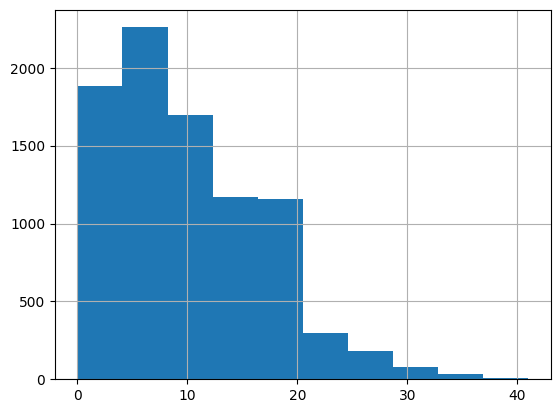

In [115]:
final['windspeed'].hist()
# y축은 row 의 수 , x축은 바람의 세기
# 5 계급이 바람의 세기 29부터인데 29를 넘는게 몇개 없는걸 확인할 수 있다 -> 있긴 있음

In [116]:
# 바람의 세기가 사람에 영향을 주는 지점(29 이상) 이상일 때, 
# 바람에게 영향을 받았다고 가정
final['windforce'] = 0
final.loc[final['windspeed'] >= 29, 'windforce'] = 1
final.head()

,datetime,temp,dew,humid,windspeed,Unnamed: 0,미세먼지(PM10),초미세먼지(PM2.5),windforce
0,2022-01-01 00:00:00,-9.0,-18.0,48.0,7.0,0,22.0,7.0,0
1,2022-01-01 01:00:00,-11.0,-17.0,62.0,6.0,1,29.0,10.0,0
2,2022-01-01 02:00:00,-11.0,-17.0,62.0,2.0,2,25.0,9.0,0
3,2022-01-01 03:00:00,-12.0,-18.0,61.0,2.0,3,27.0,9.0,0
4,2022-01-01 04:00:00,-13.0,-17.0,72.0,4.0,4,20.0,7.0,0


- 불쾌지수 (humidex)
    - T 공기는 °C 단위의 공기 온도입니다.
    - T이슬은 이슬점 온도 (° C)입니다.
    - e = 2.71828은 오일러 수의 근사치입니다. https://en.wikipedia.org/wiki/Humidex

In [117]:
# 불쾌지수는 온도(temp)와 이슬점(dew)을 이용해 땀이 증발하는 속도를 계산해 알아냄 
def humidex_cal(T, Td):
    upper = 5417.7530*(1/273.16 - 1/(273.15+Td))
    inner = 6.11 * (2.71828 **upper)
    return  T + 0.5555*(inner - 10)
final['humidex'] = humidex_cal(final['temp'], final['dew'])
display(final.head(2))
# humidex 에 따라서 느끼는 불쾌감을 따로 칼럼을 만들기
final['discomfort'] = 0
final.loc[final['humidex'] >= 30, 'discomfort'] = 1
final.loc[final['humidex'] >= 40, 'discomfort'] = 2
final.loc[final['humidex'] >= 46, 'discomfort'] = 3
final.head(2)
# 숫자가 올라갈수록 불쾌

,datetime,temp,dew,humid,windspeed,Unnamed: 0,미세먼지(PM10),초미세먼지(PM2.5),windforce,humidex
0,2022-01-01 00:00:00,-9.0,-18.0,48.0,7.0,0,22.0,7.0,0,-13.718002
1,2022-01-01 01:00:00,-11.0,-17.0,62.0,6.0,1,29.0,10.0,0,-15.645662


,datetime,temp,dew,humid,windspeed,Unnamed: 0,미세먼지(PM10),초미세먼지(PM2.5),windforce,humidex,discomfort
0,2022-01-01 00:00:00,-9.0,-18.0,48.0,7.0,0,22.0,7.0,0,-13.718002,0
1,2022-01-01 01:00:00,-11.0,-17.0,62.0,6.0,1,29.0,10.0,0,-15.645662,0


In [118]:
final.to_csv('data/final_weather.csv', index = False)

In [119]:
final

,datetime,temp,dew,humid,windspeed,Unnamed: 0,미세먼지(PM10),초미세먼지(PM2.5),windforce,humidex,discomfort
0,2022-01-01 00:00:00,-9.0,-18.0,48.0,7.0,0,22.0,7.0,0,-13.718002,0
1,2022-01-01 01:00:00,-11.0,-17.0,62.0,6.0,1,29.0,10.0,0,-15.645662,0
2,2022-01-01 02:00:00,-11.0,-17.0,62.0,2.0,2,25.0,9.0,0,-15.645662,0
3,2022-01-01 03:00:00,-12.0,-18.0,61.0,2.0,3,27.0,9.0,0,-16.718002,0
4,2022-01-01 04:00:00,-13.0,-17.0,72.0,4.0,4,20.0,7.0,0,-17.645662,0
...,...,...,...,...,...,...,...,...,...,...,...
8755,2022-12-31 19:00:00,-1.0,-6.0,69.0,4.0,8755,52.0,29.0,0,-4.382565,0
8756,2022-12-31 20:00:00,-4.0,-8.0,74.0,4.0,8756,57.0,33.0,0,-7.690710,0
8757,2022-12-31 21:00:00,-3.0,-6.0,80.0,4.0,8757,53.0,34.0,0,-6.382565,0
8758,2022-12-31 22:00:00,-4.0,-6.0,86.0,6.0,8758,57.0,36.0,0,-7.382565,0


In [120]:
all_df

,대여소번호,운동량,이용건수,이용시간(분),탄소량,이동거리(M),type,gender,age,datetime
0,1725,0.00,1,44,0.00,0.00,regular,U,10s,2022-01-01 0:00:00
1,1167,52.51,1,15,0.51,2210.00,regular,U,10s,2022-01-01 0:00:00
2,1059,25.66,1,4,0.25,1080.00,regular,U,10s,2022-01-01 0:00:00
3,3794,49.61,1,15,0.50,2160.00,regular,U,10s,2022-01-01 0:00:00
4,4014,23.60,1,7,0.22,961.30,regular,U,10s,2022-01-01 0:00:00
...,...,...,...,...,...,...,...,...,...,...
36160482,262,29.15,1,5,0.21,920.00,regular,M,unknown,2022-12-31 23:00:00
36160483,201,15.36,1,3,0.10,430.88,regular,M,unknown,2022-12-31 23:00:00
36160484,1008,36.83,1,7,0.29,1240.00,regular,M,unknown,2022-12-31 23:00:00
36160485,1637,222.14,1,87,2.00,8630.00,regular,M,unknown,2022-12-31 23:00:00
